## Settings 

In [1]:
import os 
from pathlib import Path 

PROBLEM = "code_search" 
TYPE = "scb" 
AGENT = "codex" 
MODEL = "gpt-5.6-luna"
MODES = ["noDesign", "auto", "autoNoMetric", "autoTest"]   

# List all the directories found 
if TYPE == "custom": 
    dirs = [
        Path(f"datasets/custom/problems/{PROBLEM}/implementations_{x}_{AGENT}_{MODEL}") for x in MODES
    ]
elif TYPE == "scb": 
    dirs = [
        Path(f"datasets/slopCodeBench/scb-problems/{PROBLEM}/implementations_{x}_{AGENT}_{MODEL}") for x in MODES
    ]
else: 
    raise Exception(f"Invalid problem type: {TYPE}")

# Verify if the paths exist (also verifies if the problem is valid) 
for path in dirs: 
    if not path.exists(): 
        raise Exception(f"Path does not exist: {path}")
dirs


[PosixPath('datasets/slopCodeBench/scb-problems/code_search/implementations_noDesign_codex_gpt-5.6-luna'),
 PosixPath('datasets/slopCodeBench/scb-problems/code_search/implementations_auto_codex_gpt-5.6-luna'),
 PosixPath('datasets/slopCodeBench/scb-problems/code_search/implementations_autoNoMetric_codex_gpt-5.6-luna'),
 PosixPath('datasets/slopCodeBench/scb-problems/code_search/implementations_autoTest_codex_gpt-5.6-luna')]

## Read from cached evaluation metrics

In [ ]:
import json 

# References metrics are the github metrics 
with open("metrics_cache/references_metrics.json", 'r') as f: 
    references_metrics = json.load(f) 

# scb metrics are the agent implemented scb dataset problems metrics 
with open("metrics_cache/scb_metrics.json", 'r') as f: 
    scb_metrics = json.load(f) 

with open("metrics_cache/scb_report_metrics.json", 'r') as f: 
    scb_report_metrics = json.load(f) 

with open("metrics_cache/scb_test_metrics.json", 'r') as f: 
    scb_test_metrics = json.load(f) 

## Reusable plot function

In [19]:
from matplotlib import pyplot as plt 
import math 
from reusables.interpolation import linear_interpolation
import matplotlib as mpl
import numpy as np

# Metrics must be in the form of { mode1: [{}, {}, ...], mode2: ... }<- one array for one mode]
# Metrics names must be in the form of array stating which metric to plot 
# With references = whether or not to show github repo analysis of the same metrics, side by side 
def plot(metrics_json, metrics_names, with_references = False): 
    N = len(metrics_names) 
    ROWS = math.ceil(N/2) if N > 2 else 1 
    COLS = 2 if N >= 2 else 1

    # special case hard code rows = 1 cols = 3 if N == 3 
    if N == 3: 
        ROWS = 1 
        COLS = 3 
        
    figsize = (5*COLS, 5*ROWS)
    fig, axes = plt.subplots(ROWS, COLS, figsize=figsize)
    if N > 3: 
        axes = np.atleast_1d(axes).flatten()

    if N == 1: 
        axes = [axes] # weird matplotlib feature 

    # Use different colors for metrics and ref
    metric_colors = mpl.colormaps["tab10"].resampled(max(len(MODES), 1))
    ref_colors = mpl.colormaps["Greys"].resampled(max(len(references_metrics), 1) + 2) if with_references else None

    for i, metric in enumerate(metrics_names): 
        ax = axes[i]

        l = 0 
        for (j, mode) in enumerate(MODES):
            # Obtain the data from the given metrics 
            suffix = f"_{mode}_{AGENT}_{MODEL}"

            for (key, value) in metrics_json[PROBLEM].items(): 
                if key.endswith(suffix): 
                    data = [x[metric] for x in value]
                    l = max(l, len(data))
                    break 
            
            x = range(1, len(data) + 1) 
            y = data
                
            ax.plot(x, y, label=MODES[j], color=metric_colors(j),linestyle="-",)

        # Obtain the length of the metric above 
        N_data = l

        if with_references: 
            for k, (key, value) in enumerate(references_metrics.items()):
                # Obtain the list of metric from the value 
                reference_metric_list = [x.get(metric, 0) for x in value]

                # Linear interpolate the reference metric 
                reference_metric_list_interpolated = linear_interpolation(reference_metric_list, N_data)

                # Plot on the same graph 
                x = range(1, len(reference_metric_list_interpolated) + 1) 
                y = reference_metric_list_interpolated
                ax.plot(x, y, color=ref_colors(k + 1), linestyle="--",)  # label=f"Ref: {key}"

        ax.set_xlabel("Checkpoint number")
        ax.set_ylabel(metric)
        ax.set_title(PROBLEM)
        ax.legend()

    plt.tight_layout()
    plt.show()

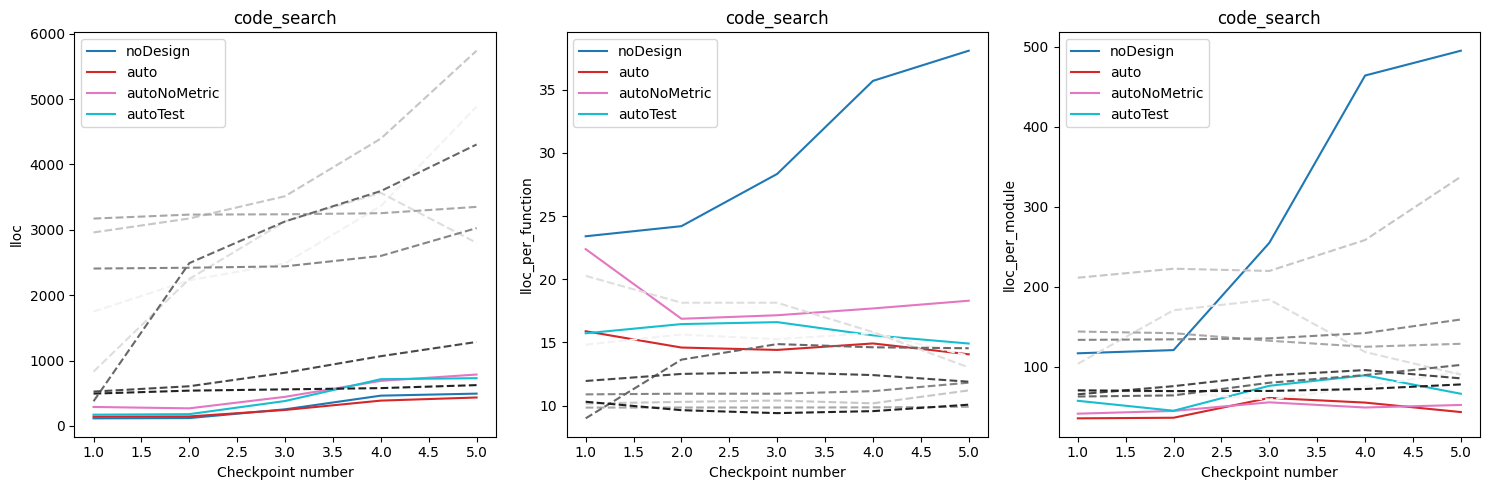

In [20]:
plot(scb_metrics, ["lloc", "lloc_per_function", "lloc_per_module"], with_references=True)